# Model Deffuanta — dynamika opinii w populacji agentów

**Na podstawie:** Deffuant, Neau, Amblard, Weisbuch (2000)

## Model

$N$ agentów z ciągłymi opiniami $x_i \in [0, 1]$, losowanymi z $U[0,1]$.
W każdym kroku losowa para $(i, j)$ wchodzi w interakcję **tylko jeśli** $|x_i - x_j| < d$:

$$x_i \leftarrow x_i + \mu (x_j - x_i), \qquad x_j \leftarrow x_j + \mu (x_i - x_j)$$

**Kluczowy wynik:** $p_{\max} \approx \dfrac{1}{2d}$ klastrów.

### Uwaga o ekstremistach

Przy dużych $d$ (np. 0.3, 0.5) mogą pojawić się pojedynczy **izolowani ekstremiści** —
agenci z opiniami bliskimi 0 lub 1, którzy mieli pecha i nigdy nie znaleźli
wystarczająco bliskiego partnera. Mają ich **co najwyżej kilkanaście** na 1000 agentów.
Artykuł opisuje ich jako osobny efekt, nie jako klastry.
Funkcja `policz_klastry` ignoruje grupy mniejsze niż $\sqrt{N}$ agentów.

| Sekcja | Temat | Odpowiednik |
|--------|-------|-------------|
| §1 | Funkcje podstawowe | — |
| §2 | Ewolucja, histogram, końcowe vs początkowe | Rys. 1–3 |
| §3 | Porównanie progów $d$ | Rys. 4 |
| §4 | Statystyka klastrów vs $d$ | Rys. 4 |
| §5 | Wpływ $\mu$ | Sekcja 2.2 |
| §6 | Model na siatce — perkolacja | Rys. 5–7 |
| §7 | Opinie wektorowe — ortogonalizacja | Rys. 8–9 |
| §8 | Interaktywna symulacja (ipywidgets) | — |


## §1. Funkcje podstawowe

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

%matplotlib inline
plt.rcParams.update({'figure.dpi': 140, 'font.size': 10, 'axes.titlesize': 11})

In [2]:
def deffuant(N=1000, d=0.25, mu=0.5, n_steps=500_000,
             snapshot_every=1000, seed=None):
    """
    Model Deffuanta — complete mixing.
    Zwraca: (x0, snapshots, x_final)
    """
    rng = np.random.default_rng(seed)
    x   = rng.uniform(0.0, 1.0, N)
    x0  = x.copy()
    snapshots = [(0, x.copy())]

    for step in range(1, n_steps + 1):
        i = rng.integers(N)
        j = rng.integers(N - 1)
        if j >= i:
            j += 1
        diff = x[j] - x[i]
        if abs(diff) < d:
            x[i] += mu * diff
            x[j] -= mu * diff
        if step % snapshot_every == 0:
            snapshots.append((step, x.copy()))

    return x0, snapshots, x.copy()

def policz_klastry(x, d):
    """
    Zlicza znaczące klastry, ignorując izolowanych ekstremistów.
    Próg minimalnego rozmiaru klastra = sqrt(N).
    Dla N=1000: próg = 32 agentów.
    Ekstremiści mają co najwyżej kilkanaście agentów — zawsze poniżej progu.
    Klastry mają dziesiątki lub setki agentów — zawsze powyżej progu.
    eps = d*0.5 oddziela klastry (oddalone o >= 2d) bez fałszywych podziałów
    wewnątrz klastra — szerokość klastra jest rzędu ~0.01, więc eps=d*0.5
    bezpiecznie mieści się między (szerokość_klastra, 2d).
    """
    min_size = max(2, int(np.sqrt(len(x))))
    eps      = d * 0.5          # było d*0.3, za małe
    s        = np.sort(x)
    breaks   = np.where(np.diff(s) > eps)[0] + 1
    groups   = np.split(s, breaks)
    return len([g for g in groups if len(g) >= min_size])

def pozycje_klastrow(x, d):
    """Środki ciężkości znaczących klastrów.
    Używa mediany zamiast średniej — odporna na outlierów w ogonach klastra.
    eps = d*0.5 — analogicznie jak w policz_klastry.
    """
    min_size = max(2, int(np.sqrt(len(x))))
    eps      = d * 0.5
    s        = np.sort(x)
    breaks   = np.where(np.diff(s) > eps)[0] + 1
    groups   = np.split(s, breaks)
    return [np.median(g) for g in groups if len(g) >= min_size]

## §2. Pojedyncze uruchomienie — odtworzenie Rysunków 1–3

- **Górny panel:** ewolucja czasowa
- **Dolny lewy:** histogram końcowy
- **Dolny prawy:** opinia końcowa vs początkowa

In [3]:
# === Parametry ===
N       = 1000
d       = 0.2
mu      = 0.5
n_steps = 500_000
# ==================

x0, snaps, xf = deffuant(N=N, d=d, mu=mu, n_steps=n_steps)
nc  = policz_klastry(xf, d=d)
pos = pozycje_klastrow(xf, d=d)
print(f'Klastrów: {nc}  (p_max = {int(1/(2*d))})')
print(f'Pozycje:  {[round(p, 3) for p in pos]}')

Klastrów: 2  (p_max = 2)
Pozycje:  [np.float64(0.249), np.float64(0.684)]


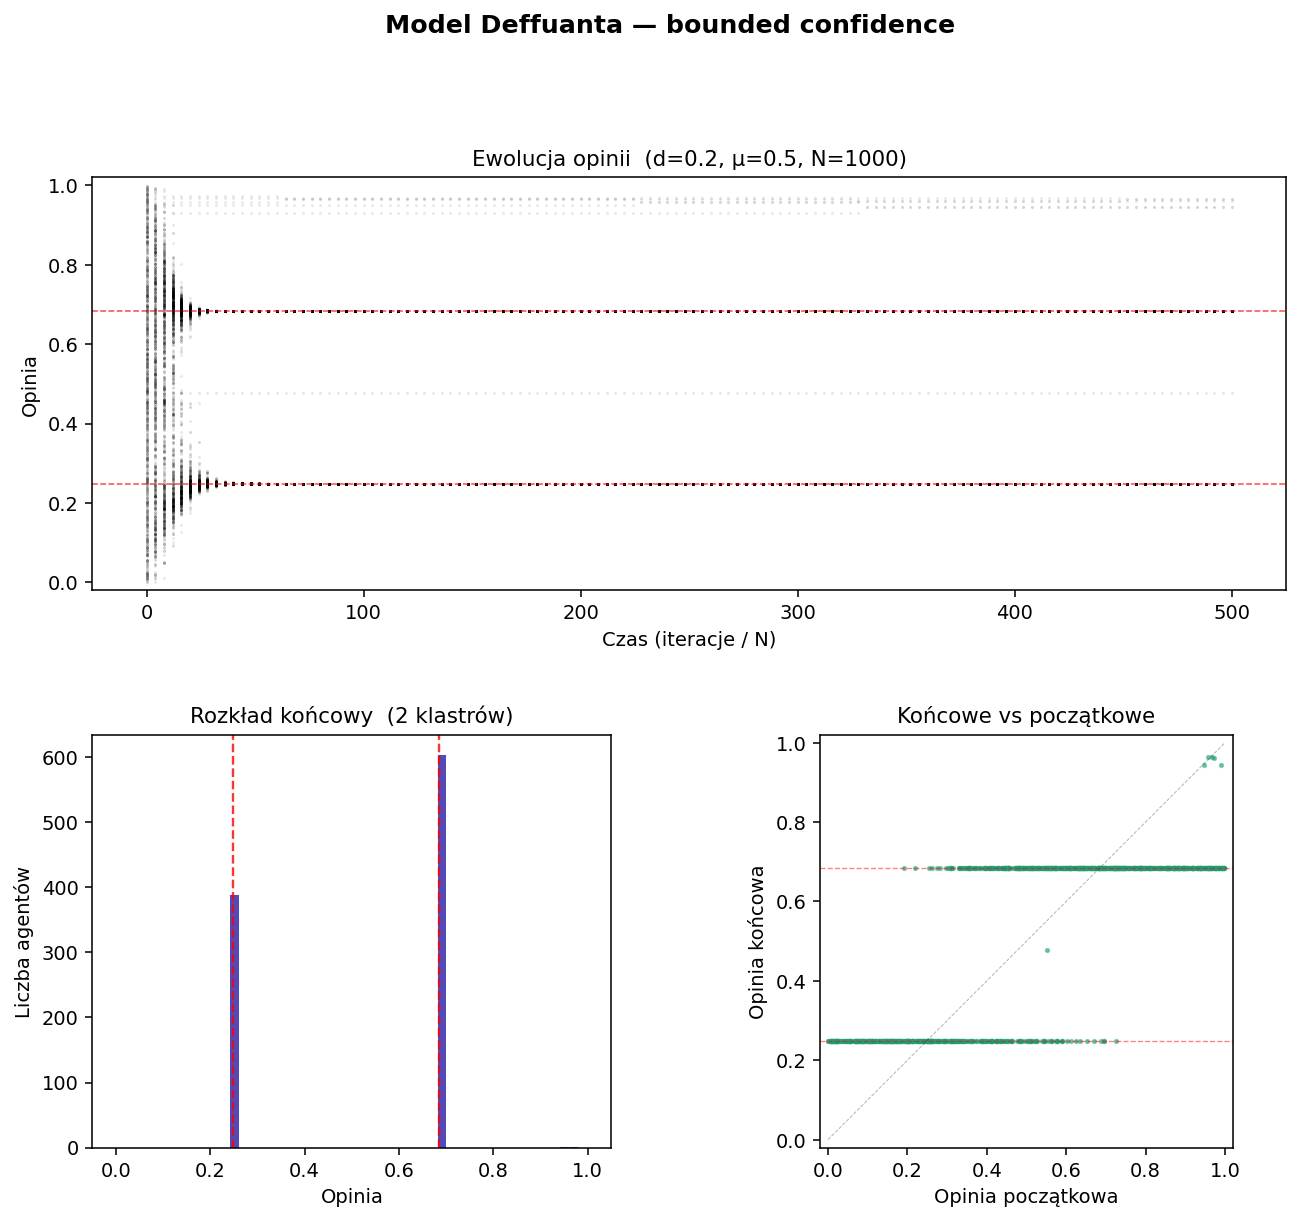

In [4]:
fig = plt.figure(figsize=(11, 9))
gs  = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax1  = fig.add_subplot(gs[0, :])
krok = max(1, len(snaps) // 120)
for idx in range(0, len(snaps), krok):
    t, ops = snaps[idx]
    ax1.scatter([t/N]*len(ops), ops, s=0.15, c='black', alpha=0.12,
                rasterized=True)
for p in pos:
    ax1.axhline(p, color='red', lw=0.8, ls='--', alpha=0.7)
ax1.set_xlabel('Czas (iteracje / N)')
ax1.set_ylabel('Opinia')
ax1.set_ylim(-0.02, 1.02)
ax1.set_title(f'Ewolucja opinii  (d={d}, μ={mu}, N={N})')

ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(xf, bins=50, range=(0,1), color='#534AB7', edgecolor='white', lw=0.5)
for p in pos:
    ax2.axvline(p, color='red', lw=1.2, ls='--', alpha=0.8)
ax2.set_xlabel('Opinia'); ax2.set_ylabel('Liczba agentów')
ax2.set_title(f'Rozkład końcowy  ({nc} klastrów)')

ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(x0, xf, s=3, c='#1D9E75', alpha=0.5, rasterized=True)
ax3.plot([0,1],[0,1],'k--',lw=0.5,alpha=0.3)
for p in pos:
    ax3.axhline(p, color='red', lw=0.7, ls='--', alpha=0.5)
ax3.set_xlabel('Opinia początkowa'); ax3.set_ylabel('Opinia końcowa')
ax3.set_xlim(-0.02,1.02); ax3.set_ylim(-0.02,1.02); ax3.set_aspect('equal')
ax3.set_title('Końcowe vs początkowe')

plt.suptitle('Model Deffuanta — bounded confidence',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

## §3. Porównanie progów $d$ — odtworzenie Rysunku 4

$d$ kontroluje liczbę klastrów. $\mu$ i $N$ wpływają tylko na czas zbieżności.

Czerwone kreski na wykresach ewolucji = pozycje znaczących klastrów.
Szare kropki poniżej/powyżej = izolowani ekstremiści (nie liczone jako klastry).

d=0.50 → 1 klastrów  (p_max = 1)
d=0.30 → 1 klastrów  (p_max = 1)
d=0.20 → 2 klastrów  (p_max = 2)
d=0.15 → 3 klastrów  (p_max = 3)
d=0.10 → 4 klastrów  (p_max = 5)
d=0.05 → 8 klastrów  (p_max = 10)


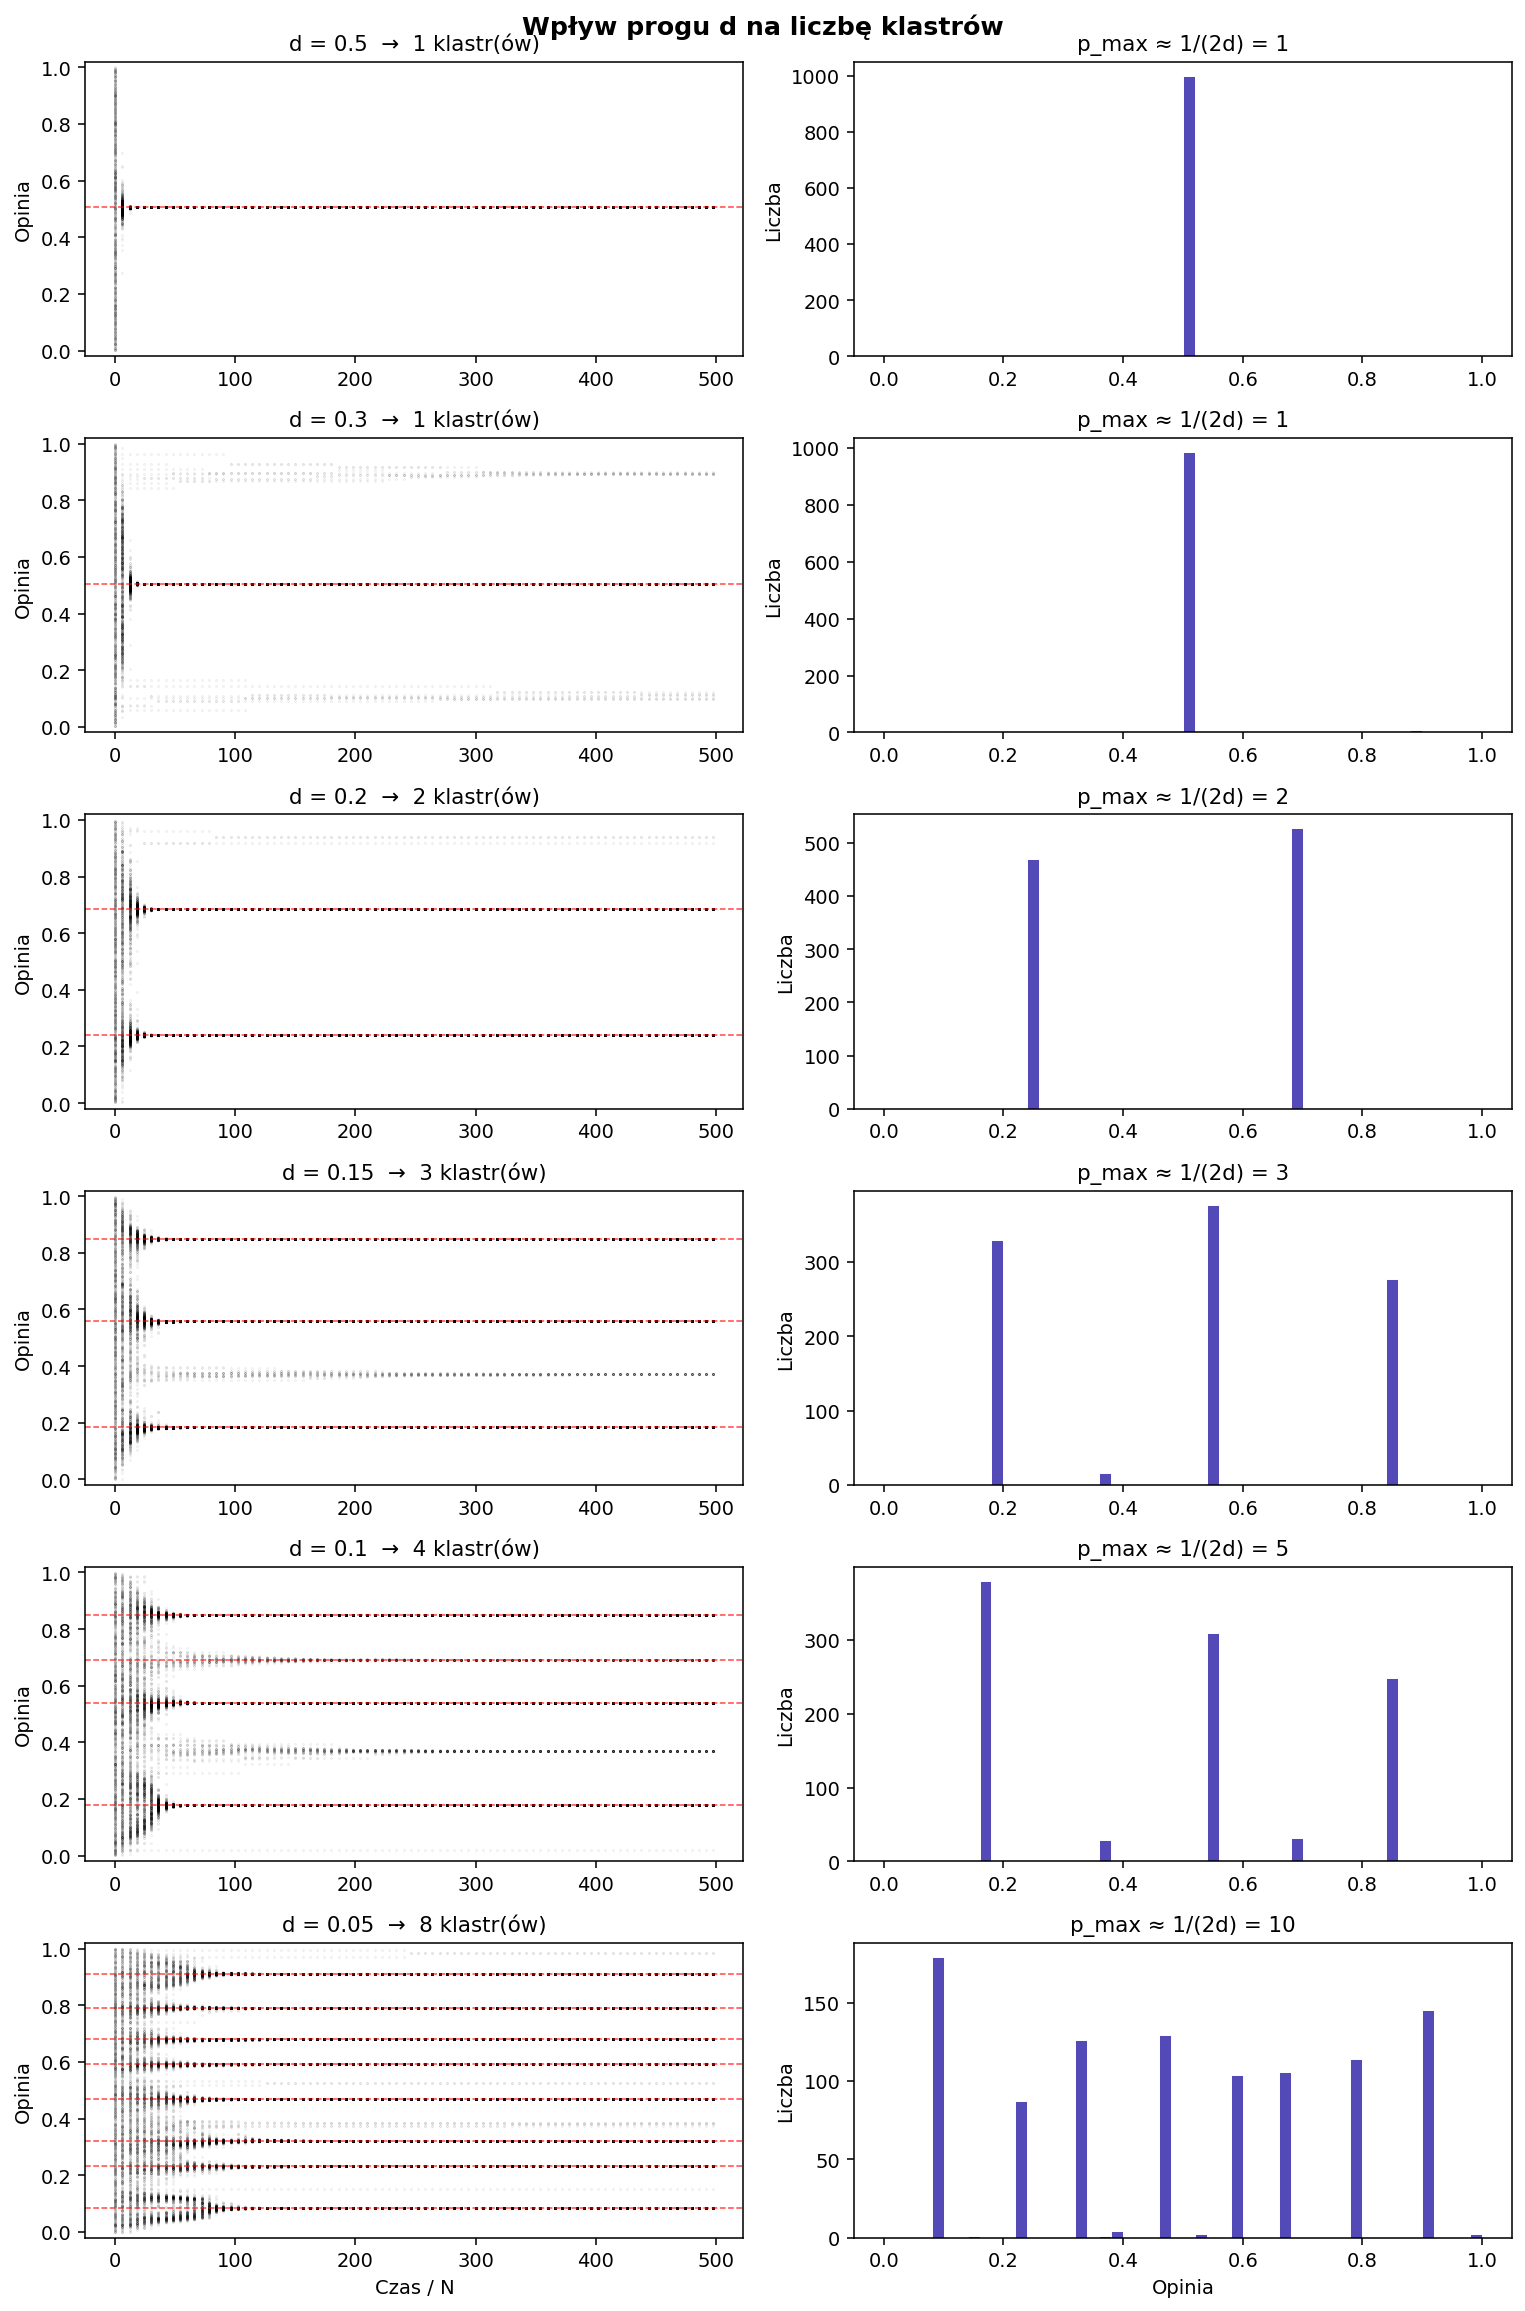

In [5]:
progi = [0.5, 0.3, 0.2, 0.15, 0.1, 0.05]

fig, axes = plt.subplots(len(progi), 2, figsize=(11, 2.8*len(progi)))

for row, d_val in enumerate(progi):
    x0_t, snaps_t, xf_t = deffuant(N=1000, d=d_val, mu=0.5, n_steps=500_000)
    nc_t   = policz_klastry(xf_t, d=d_val)
    pmax_t = max(1, int(1/(2*d_val)))
    pos_t  = pozycje_klastrow(xf_t, d=d_val)
    print(f'd={d_val:.2f} → {nc_t} klastrów  (p_max = {pmax_t})')

    ax_l = axes[row, 0]
    krok  = max(1, len(snaps_t) // 80)
    for idx in range(0, len(snaps_t), krok):
        t, ops = snaps_t[idx]
        ax_l.scatter([t/1000]*len(ops), ops, s=0.1, c='black',
                     alpha=0.1, rasterized=True)
    for p in pos_t:
        ax_l.axhline(p, color='red', lw=0.8, ls='--', alpha=0.7)
    ax_l.set_ylim(-0.02, 1.02)
    ax_l.set_ylabel('Opinia')
    ax_l.set_title(f'd = {d_val}  →  {nc_t} klastr(ów)')
    if row == len(progi)-1:
        ax_l.set_xlabel('Czas / N')

    ax_r = axes[row, 1]
    ax_r.hist(xf_t, bins=50, range=(0,1), color='#534AB7',
              edgecolor='white', lw=0.5)
    ax_r.set_ylabel('Liczba')
    ax_r.set_title(f'p_max ≈ 1/(2d) = {pmax_t}')
    if row == len(progi)-1:
        ax_r.set_xlabel('Opinia')

plt.suptitle('Wpływ progu d na liczbę klastrów',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## §4. Statystyka liczby klastrów vs $d$

Wiele przebiegów dla każdego $d$. Czerwona krzywa = $p_{\max} = 1/(2d)$.

d=0.050: śr=8.6, min=7, max=10
d=0.075: śr=5.8, min=5, max=7
d=0.100: śr=4.4, min=3, max=5
d=0.125: śr=3.4, min=3, max=4
d=0.150: śr=2.9, min=2, max=3
d=0.175: śr=2.6, min=2, max=3
d=0.200: śr=2.0, min=2, max=2
d=0.225: śr=2.0, min=2, max=2
d=0.250: śr=1.9, min=1, max=2
d=0.275: śr=1.4, min=1, max=2
d=0.300: śr=1.0, min=1, max=1
d=0.325: śr=1.0, min=1, max=1
d=0.350: śr=1.0, min=1, max=1
d=0.375: śr=1.0, min=1, max=1
d=0.400: śr=1.0, min=1, max=1
d=0.425: śr=1.0, min=1, max=1
d=0.450: śr=1.0, min=1, max=1
d=0.475: śr=1.0, min=1, max=1
d=0.500: śr=1.0, min=1, max=1


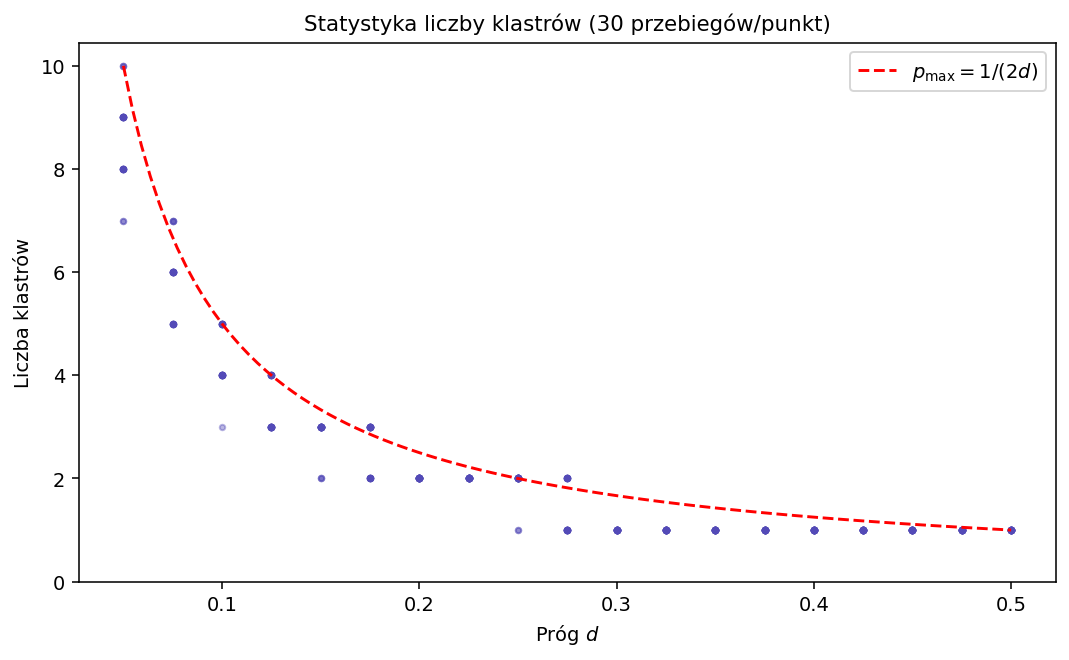

In [6]:
d_values  = np.arange(0.05, 0.51, 0.025)
n_samples = 30

wyniki = {}
for dv in d_values:
    wyniki[dv] = []
    for _ in range(n_samples):
        _, _, xf_s = deffuant(N=1000, d=float(dv), mu=0.5, n_steps=500_000)
        wyniki[dv].append(policz_klastry(xf_s, d=float(dv)))
    m = np.mean(wyniki[dv])
    print(f'd={dv:.3f}: śr={m:.1f}, min={min(wyniki[dv])}, max={max(wyniki[dv])}')

fig, ax = plt.subplots(figsize=(9, 5))
for dv in d_values:
    ax.scatter([dv]*len(wyniki[dv]), wyniki[dv], s=8, c='#534AB7', alpha=0.4)
d_t = np.linspace(0.05, 0.5, 100)
ax.plot(d_t, 1/(2*d_t), 'r--', lw=1.5, label=r'$p_{\max}=1/(2d)$')
ax.set_xlabel('Próg $d$'); ax.set_ylabel('Liczba klastrów')
ax.set_title(f'Statystyka liczby klastrów ({n_samples} przebiegów/punkt)')
ax.legend(); ax.set_ylim(0, None)
plt.show()

## §5. Wpływ parametru $\mu$

$\mu$ wpływa tylko na **szybkość zbieżności** i ostrość granic, **nie na liczbę klastrów**.

Żeby to pokazać uczciwie, używamy **tych samych losowań** $(i,j)$ dla każdego $\mu$.
Bez tego różnice w liczbie klastrów mogłyby być efektem losowości, a nie $\mu$.

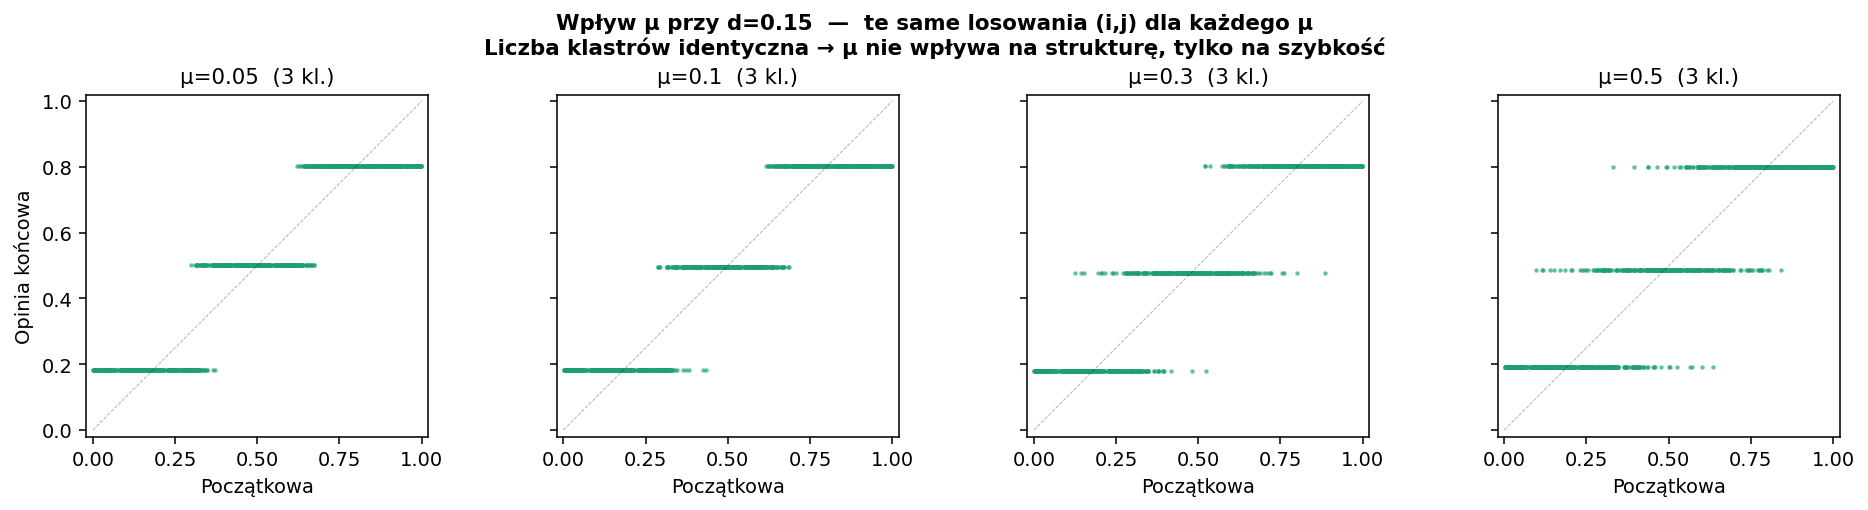

In [7]:
mu_values = [0.05, 0.1, 0.3, 0.5]
d_fixed   = 0.15
N         = 1000
n_steps   = 500_000
seed      = 42

# Generujemy jeden zestaw: opinie startowe + sekwencja par (i,j)
# Wszystkie mu używają dokładnie tych samych losowań
rng_setup = np.random.default_rng(seed)
x_start   = rng_setup.uniform(0.0, 1.0, N)
ii        = rng_setup.integers(N, size=n_steps)
jj        = rng_setup.integers(N - 1, size=n_steps)
jj[jj >= ii] += 1  # upewniamy się że i != j

fig, axes = plt.subplots(1, len(mu_values), figsize=(14, 3.5), sharey=True)

for col, mu_val in enumerate(mu_values):
    # każdy mu startuje z tych samych opinii i używa tych samych par
    x  = x_start.copy()
    x0 = x_start.copy()

    for step in range(n_steps):
        i, j = ii[step], jj[step]
        diff = x[j] - x[i]
        if abs(diff) < d_fixed:
            x[i] += mu_val * diff
            x[j] -= mu_val * diff

    nc_m = policz_klastry(x, d=d_fixed)

    ax = axes[col]
    ax.scatter(x0, x, s=2, c='#1D9E75', alpha=0.5, rasterized=True)
    ax.plot([0,1],[0,1],'k--',lw=0.5,alpha=0.3)
    ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02)
    ax.set_aspect('equal'); ax.set_xlabel('Początkowa')
    ax.set_title(f'μ={mu_val}  ({nc_m} kl.)')

axes[0].set_ylabel('Opinia końcowa')
plt.suptitle(
    f'Wpływ μ przy d={d_fixed}  —  te same losowania (i,j) dla każdego μ\n'
    f'Liczba klastrów identyczna → μ nie wpływa na strukturę, tylko na szybkość',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

## §6. Model na siatce społecznej — odtworzenie Rysunków 5–7

Agenci na siatce $L\times L$, każdy oddziałuje z 4 sąsiadami (N,S,E,W).

In [8]:
def deffuant_siatka(L=30, d=0.3, mu=0.3, n_steps=200_000, seed=None):
    rng   = np.random.default_rng(seed)
    grid  = rng.uniform(0.0, 1.0, (L, L))
    grid0 = grid.copy()
    sasiedzi = [(-1,0),(1,0),(0,-1),(0,1)]
    for _ in range(n_steps):
        r1 = rng.integers(L); c1 = rng.integers(L)
        dr, dc = sasiedzi[rng.integers(4)]
        r2 = (r1+dr)%L; c2 = (c1+dc)%L
        diff = grid[r2,c2] - grid[r1,c1]
        if abs(diff) < d:
            grid[r1,c1] += mu*diff
            grid[r2,c2] -= mu*diff
    return grid0, grid

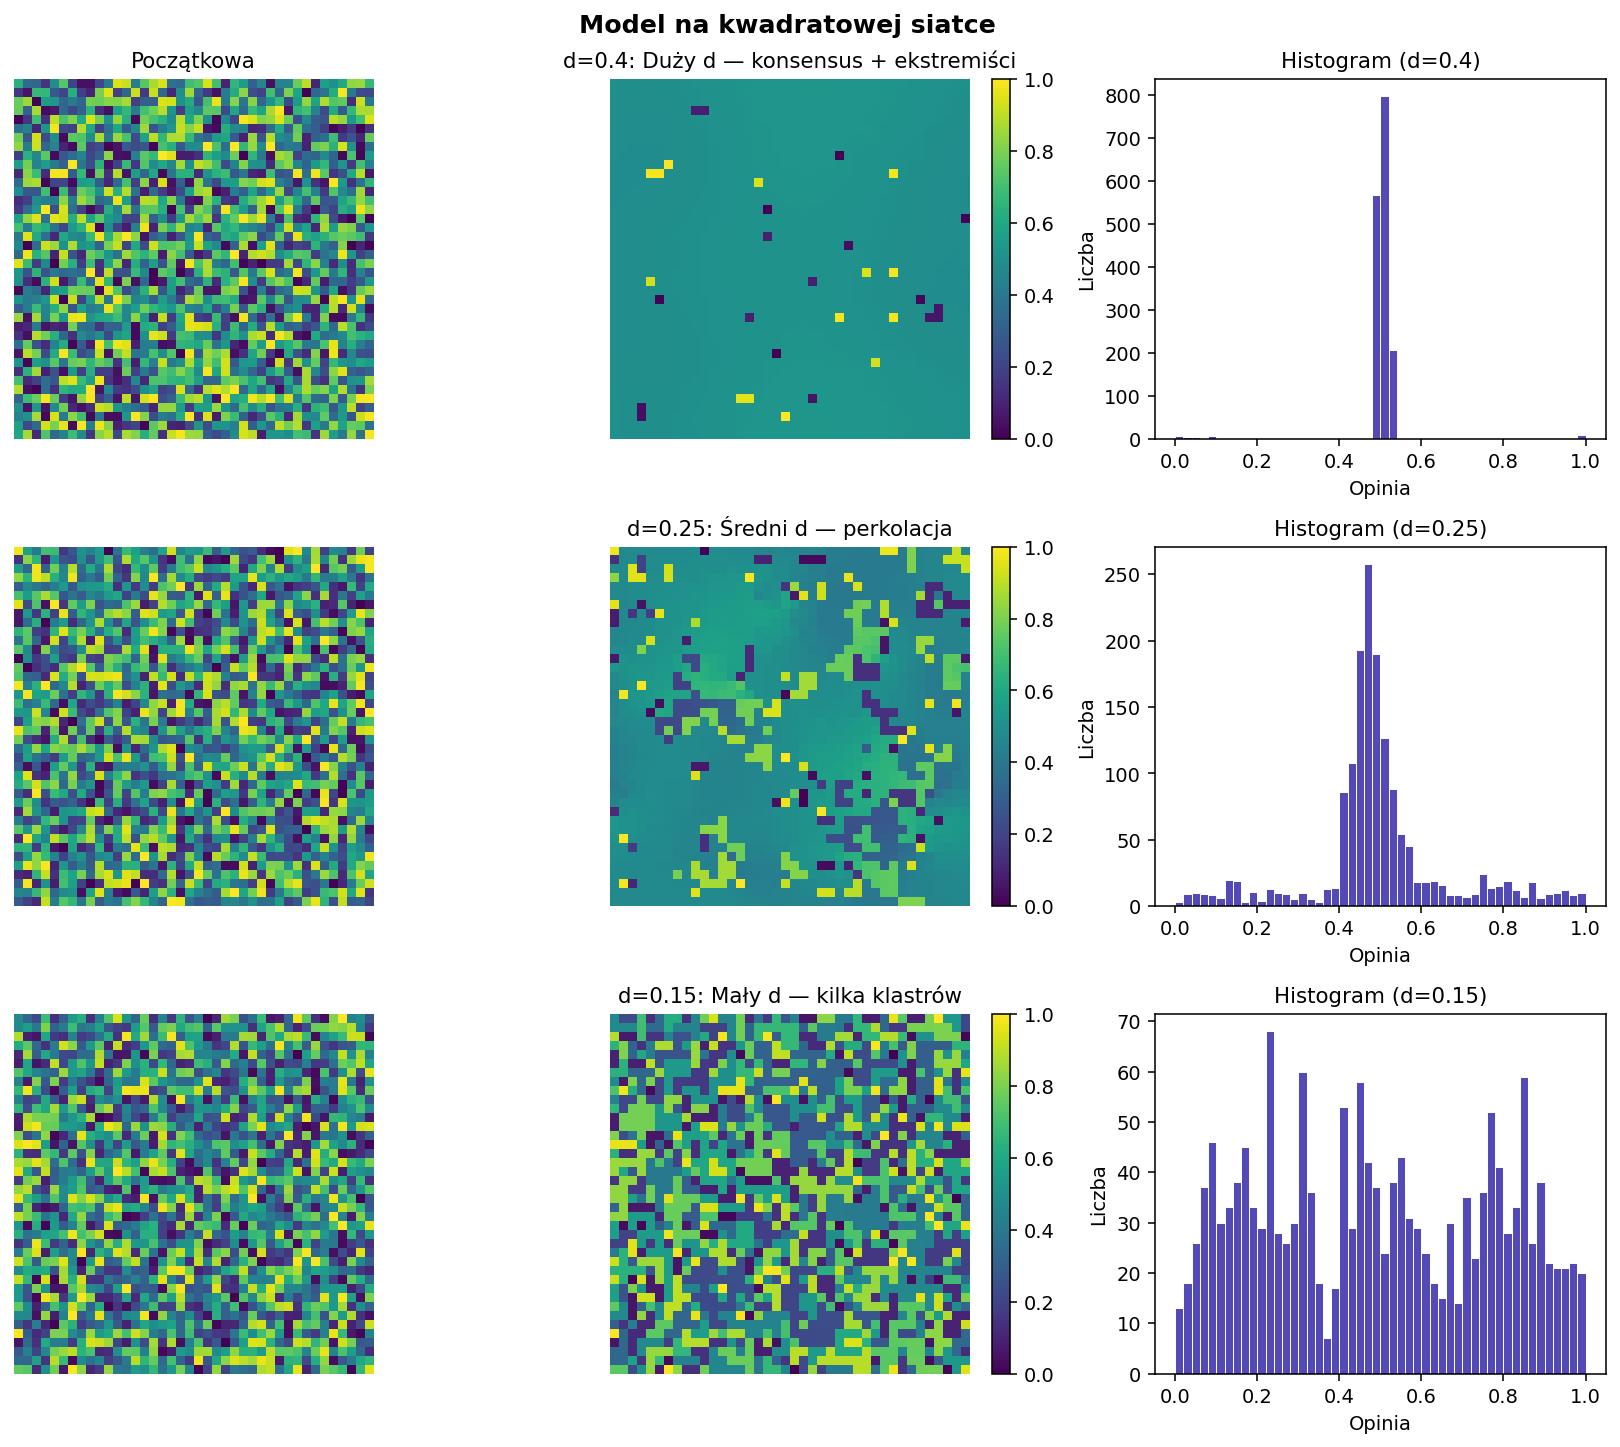

In [9]:
parametry = [
    (0.4,  'Duży d — konsensus + ekstremiści'),
    (0.25, 'Średni d — perkolacja'),
    (0.15, 'Mały d — kilka klastrów'),
]
fig, axes = plt.subplots(len(parametry), 3,
                         figsize=(12, 3.5*len(parametry)))
for row, (d_lat, tytul) in enumerate(parametry):
    g0, gf = deffuant_siatka(L=40, d=d_lat, mu=0.3, n_steps=300_000)
    axes[row,0].imshow(g0, vmin=0, vmax=1, cmap='viridis', aspect='equal')
    axes[row,0].set_title('Początkowa' if row==0 else ''); axes[row,0].axis('off')
    im = axes[row,1].imshow(gf, vmin=0, vmax=1, cmap='viridis', aspect='equal')
    axes[row,1].set_title(f'd={d_lat}: {tytul}'); axes[row,1].axis('off')
    plt.colorbar(im, ax=axes[row,1], fraction=0.046)
    axes[row,2].hist(gf.ravel(), bins=50, range=(0,1),
                     color='#534AB7', edgecolor='white', lw=0.5)
    axes[row,2].set_xlabel('Opinia'); axes[row,2].set_ylabel('Liczba')
    axes[row,2].set_title(f'Histogram (d={d_lat})')
plt.suptitle('Model na kwadratowej siatce', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## §7. Opinie wektorowe — odtworzenie Rysunków 8–9

Każdy agent ma wektor $m$ binarnych opinii. Interakcja gdy odległość Hamminga $\leq d$.
**Wynik:** ortogonalizacja — średnia $h(i,j) \approx m/2$, nie polaryzacja.

In [10]:
def deffuant_wektor(N=500, m=13, d=3, mu=0.5, n_steps=2_000_000):
    """
    Wektorowy model Deffuanta z binarnymi opiniami.
    d — maksymalna liczba niezgodności umożliwiająca interakcję.
    """
    opinie = np.random.randint(0, 2, (N, m))
    
    hist_odleglosci = []
    
    for step in range(1, n_steps + 1):
        i = np.random.randint(N)
        j = np.random.randint(N - 1)
        if j >= i:
            j += 1
        
        hamming = np.sum(opinie[i] != opinie[j])
        
        if hamming <= d:
            diff_mask = opinie[i] != opinie[j]
            for k in np.where(diff_mask)[0]:
                if np.random.random() < mu:
                    if np.random.random() < 0.5:
                        opinie[j, k] = opinie[i, k]
                    else:
                        opinie[i, k] = opinie[j, k]
        
        if step % (n_steps // 10) == 0:
            rozmiar_probki = min(5000, N * (N - 1) // 2)
            odl = []
            for _ in range(rozmiar_probki):
                a, b = np.random.choice(N, 2, replace=False)
                odl.append(np.sum(opinie[a] != opinie[b]))
            hist_odleglosci.append((step, odl))
    
    return opinie, hist_odleglosci

Uruchamianie modelu wektorowego (m=13, d=3)...


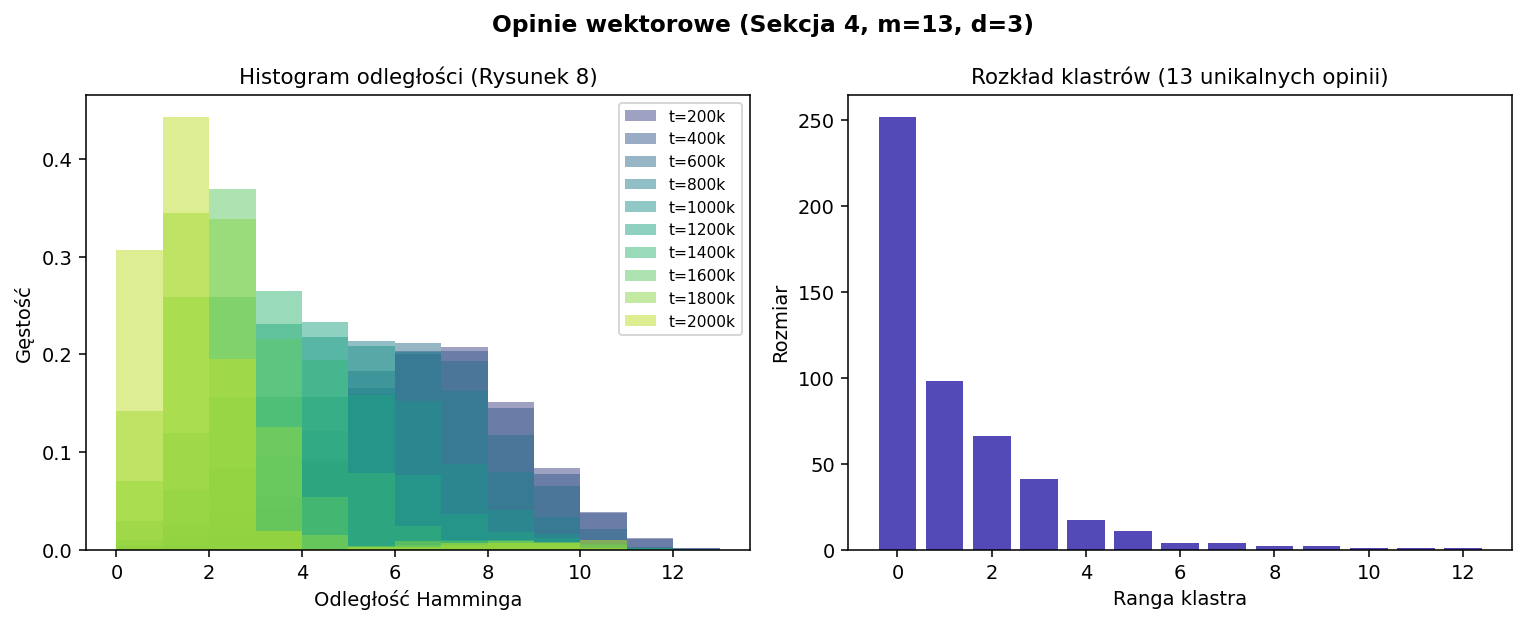


Unikalnych opinii: 13
Top 5 klastrów: [252  98  66  41  17]


In [11]:
print('Uruchamianie modelu wektorowego (m=13, d=3)...')
ops_vec, hist_odl = deffuant_wektor(N=500, m=13, d=3, mu=0.5,
                                     n_steps=2_000_000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Histogram odległości (Rysunek 8)
ax = axes[0]
kolory = plt.cm.viridis(np.linspace(0.2, 0.9, len(hist_odl)))
for idx, (t, odl) in enumerate(hist_odl):
    ax.hist(odl, bins=range(0, 14), alpha=0.5, color=kolory[idx],
            label=f't={t//1000}k', density=True)
ax.set_xlabel('Odległość Hamminga')
ax.set_ylabel('Gęstość')
ax.set_title('Histogram odległości (Rysunek 8)')
ax.legend(fontsize=8)

# Unikalne opinie i ich częstości
ax2 = axes[1]
unikalne, licznosci = np.unique(ops_vec, axis=0, return_counts=True)
licznosci_sort = np.sort(licznosci)[::-1]
ax2.bar(range(len(licznosci_sort)), licznosci_sort, color='#534AB7')
ax2.set_xlabel('Ranga klastra')
ax2.set_ylabel('Rozmiar')
ax2.set_title(f'Rozkład klastrów ({len(licznosci_sort)} unikalnych opinii)')

plt.suptitle('Opinie wektorowe (Sekcja 4, m=13, d=3)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nUnikalnych opinii: {len(licznosci_sort)}')
print(f'Top 5 klastrów: {licznosci_sort[:5]}')

## §8. Interaktywna symulacja (ipywidgets)

> `pip install ipywidgets`

In [ ]:
from ipywidgets import (FloatSlider, IntSlider, Dropdown, Button,
                        HBox, VBox, Output, HTML, Layout)
from IPython.display import display, clear_output

_s = {'description_width': '175px'}
_l = Layout(width='440px')

w_d     = FloatSlider(value=0.20, min=0.05, max=0.50, step=0.05,
                      description='Próg zaufania d', style=_s, layout=_l,
                      continuous_update=False, readout_format='.2f')
w_mu    = FloatSlider(value=0.30, min=0.05, max=0.50, step=0.05,
                      description='Zbieżność μ', style=_s, layout=_l,
                      continuous_update=False, readout_format='.2f')
w_N     = IntSlider(value=300, min=50, max=1000, step=50,
                    description='Agenci N', style=_s, layout=_l,
                    continuous_update=False)
w_steps = Dropdown(options=[('Szybko (50k)',50_000),
                             ('Normalnie (200k)',200_000),
                             ('Dokładnie (500k)',500_000)],
                   value=200_000, description='Kroki', style=_s, layout=_l)
w_tryb  = Dropdown(options=[('Ewolucja czasowa','time'),
                             ('Histogram końcowy','hist')],
                   value='time', description='Wizualizacja', style=_s, layout=_l)
btn     = Button(description='▶ Uruchom', button_style='primary',
                 layout=Layout(width='140px', height='34px'))
out_p   = Output(); out_i = Output()


def _rysuj(x0, snapshots, xf, d, mu, N, tryb):
    nc   = policz_klastry(xf, d=d)
    pos  = pozycje_klastrow(xf, d=d)
    pmax = max(1, int(1/(2*d)))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2),
                                    gridspec_kw={'width_ratios':[2,1]})
    fig.suptitle(f'd={d:.2f}  μ={mu:.2f}  N={N}   →   {nc} klastrów  (p_max={pmax})',
                 fontsize=11, fontweight='bold')
    if tryb == 'time':
        ts = np.arange(len(snapshots))
        for i in range(0, N, max(1, N//100)):
            traj = [snapshots[t][1][i] for t in range(len(snapshots))]
            ax1.plot(ts, traj, lw=0.35, alpha=0.22, color='#2255AA')
        for p in pos:
            ax1.axhline(p, color='red', lw=0.9, ls='--', alpha=0.7)
        ax1.set_xlabel('Numer snapshotu'); ax1.set_ylabel('Opinia')
        ax1.set_ylim(-0.02, 1.02); ax1.set_title('Ewolucja czasowa')
    else:
        ax1.hist(xf, bins=60, range=(0,1), color='#534AB7',
                 edgecolor='white', lw=0.4, alpha=0.85)
        for ki in range(1, pmax+1):
            ax1.axvline((2*ki-1)/(2*pmax), color='red', lw=1.0, ls='--', alpha=0.6)
        for p in pos:
            ax1.axvline(p, color='#1D9E75', lw=1.3, ls='-', alpha=0.85)
        ax1.legend(handles=[
            mpatches.Patch(color='red',     label='Oczekiwane 1/(2d)', alpha=0.6),
            mpatches.Patch(color='#1D9E75', label='Rzeczywiste',       alpha=0.85),
        ], fontsize=8, loc='upper right')
        ax1.set_xlabel('Opinia'); ax1.set_ylabel('Liczba agentów')
        ax1.set_title('Histogram końcowy')
    ax2.scatter(x0, xf, s=4, c='#1D9E75', alpha=0.45, rasterized=True)
    ax2.plot([0,1],[0,1],'k--',lw=0.5,alpha=0.3)
    for p in pos:
        ax2.axhline(p, color='red', lw=0.7, ls='--', alpha=0.5)
    ax2.set_xlabel('Opinia początkowa'); ax2.set_ylabel('Opinia końcowa')
    ax2.set_xlim(-0.02,1.02); ax2.set_ylim(-0.02,1.02)
    ax2.set_aspect('equal'); ax2.set_title('Końcowe vs początkowe')
    plt.tight_layout(); plt.show()


def _on_run(_):
    dv, muv, Nv, sv = w_d.value, w_mu.value, w_N.value, w_steps.value
    with out_i:
        clear_output(wait=True)
        print(f'Symulacja: N={Nv}, d={dv:.2f}, μ={muv:.2f}, kroków={sv:,}...')
    x0w, sw, xfw = deffuant(N=Nv, d=dv, mu=muv, n_steps=sv)
    ncw  = policz_klastry(xfw, d=dv)
    posw = pozycje_klastrow(xfw, d=dv)
    with out_i:
        clear_output(wait=True)
        print(f'Gotowe!  Klastrów: {ncw}  (p_max={max(1,int(1/(2*dv)))})')
        print(f'Pozycje: {[round(p,3) for p in posw]}')
    with out_p:
        clear_output(wait=True)
        _rysuj(x0w, sw, xfw, dv, muv, Nv, w_tryb.value)


btn.on_click(_on_run)
display(VBox([
    HTML("<b style='font-size:13px'>Parametry symulacji</b>"),
    HBox([VBox([w_d, w_mu, w_N]), VBox([w_steps, w_tryb])]),
    HBox([btn, out_i]), out_p,
]))

## §9. Heterogeniczny próg zaufania — losowanie $d_i$ z $\mathcal{N}(\bar{d},\sigma^2)$

W klasycznym modelu wszyscy agenci mają ten sam próg $d$. Tu każdy agent $i$ ma własny próg
$d_i \sim \mathcal{N}(\bar{d},\, \sigma^2)$, obcięty do $[0.01, 1.0]$.
Interakcja $(i,j)$ zachodzi gdy $|x_i - x_j| < \min(d_i, d_j)$ — oboje muszą zgadzać się na kontakt.

**Pytania badawcze:**
- Czy heterogeniczność $d_i$ zwiększa/zmniejsza liczbę klastrów?
- Jak szerokość $\sigma$ wpływa na polaryzację?
- Czy agenci z dużym $d_i$ (otwaci) działają jak mosty między klastrami?


Heterogeniczny model Deffuanta: d_mean=0.25
   sigma    klastrów     p_max  pozycje
-------------------------------------------------------
    0.00           2         2  [np.float64(0.274), np.float64(0.688)]
    0.05           2         2  [np.float64(0.252), np.float64(0.674)]
    0.10           2         2  [np.float64(0.287), np.float64(0.5)]
    0.20           1         2  [np.float64(0.487)]


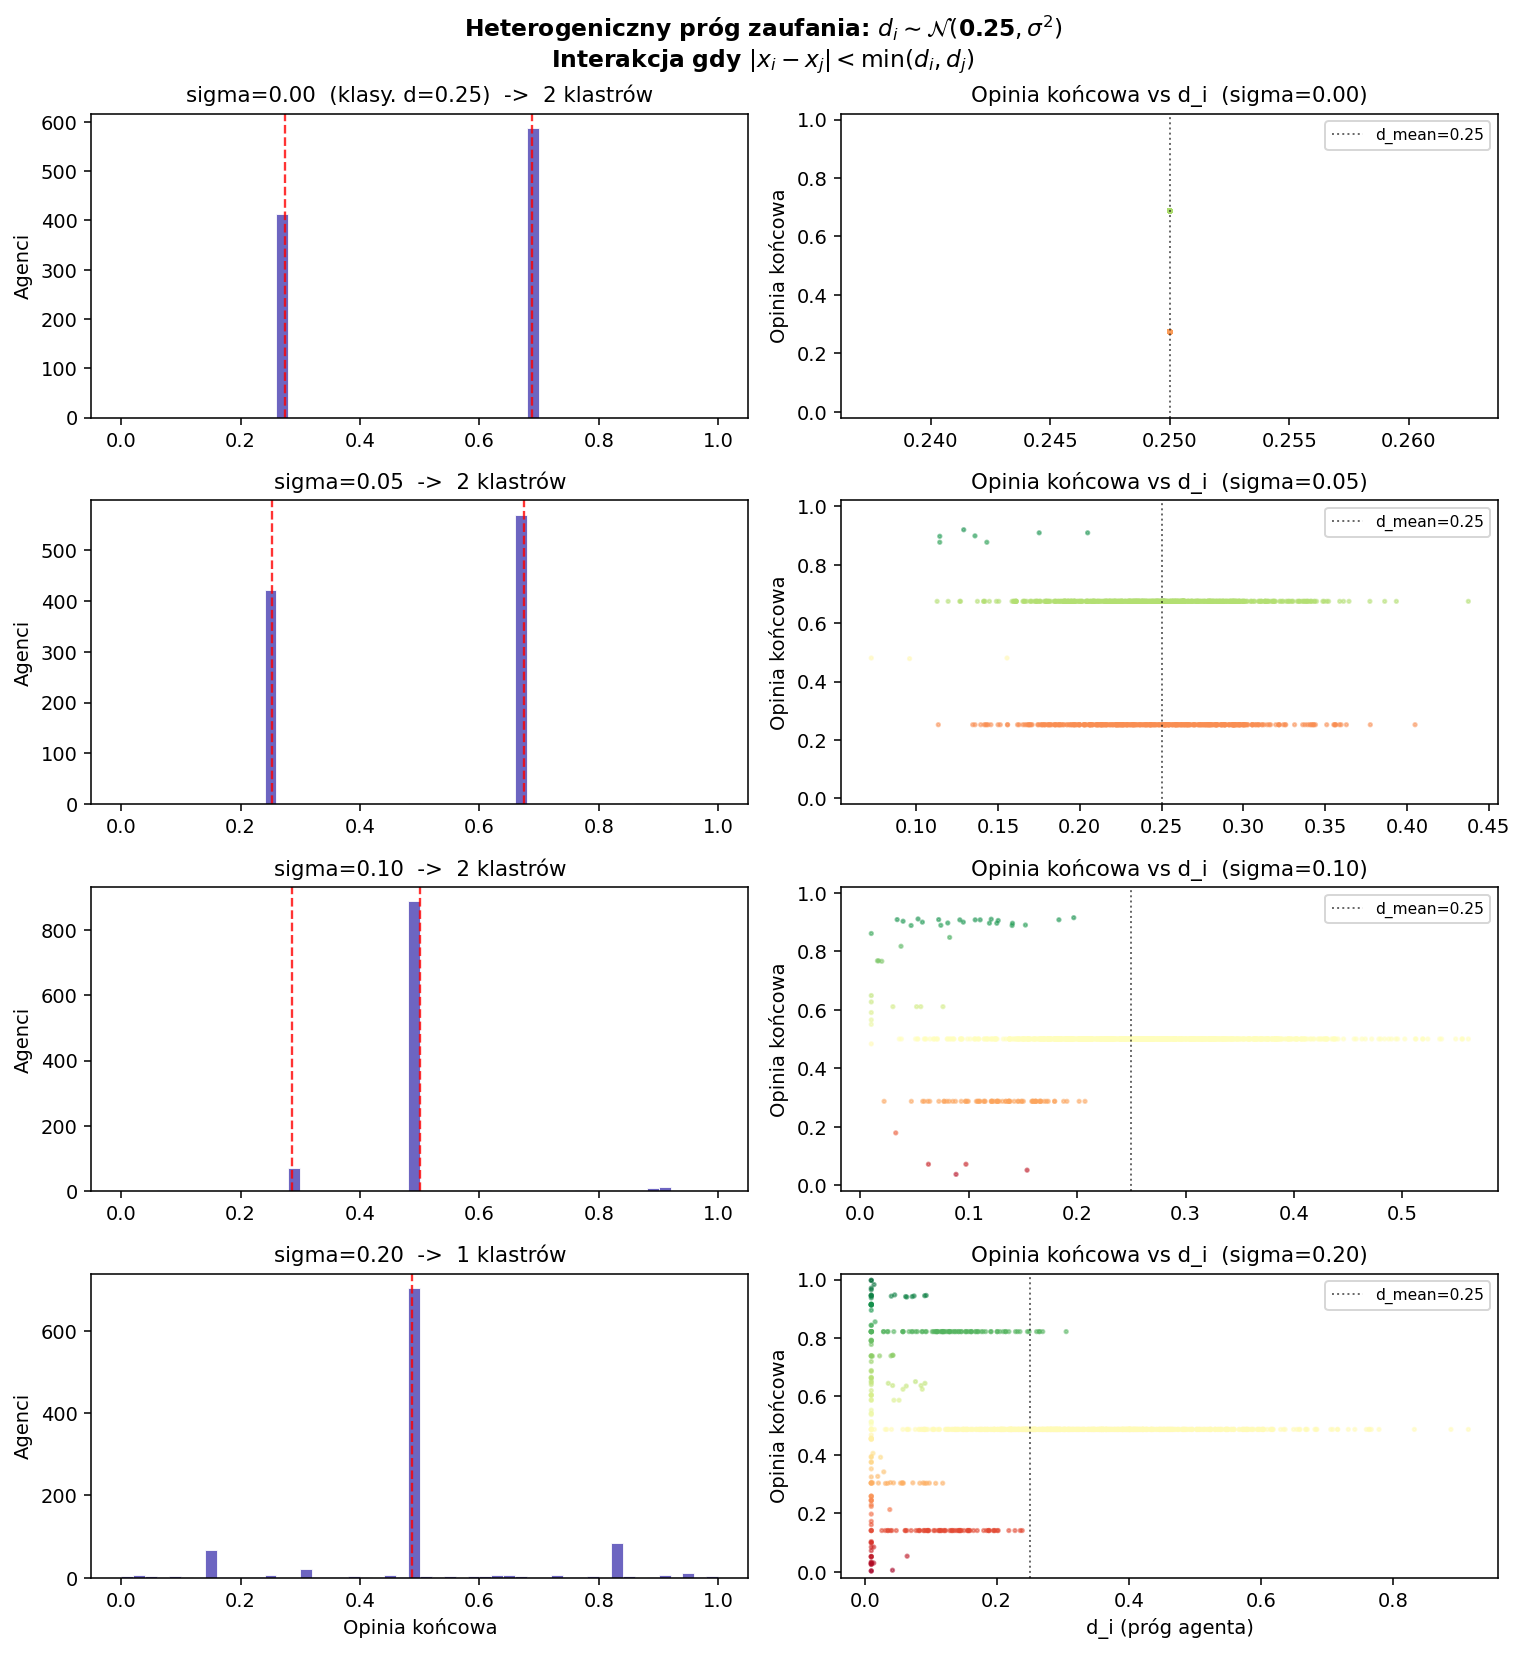

In [16]:
def deffuant_hetero(N=1000, d_mean=0.25, d_sigma=0.05,
                    mu=0.5, n_steps=500_000, seed=None):
    """
    Model Deffuanta z heterogenicznym progiem d_i ~ N(d_mean, d_sigma^2).
    Interakcja (i,j): tylko jezeli |x_i - x_j| < min(d_i, d_j).
    Zwraca: (x0, d_agents, x_final)
    """
    rng = np.random.default_rng(seed)
    d_agents = rng.normal(d_mean, d_sigma, N)
    d_agents = np.clip(d_agents, 0.01, 1.0)
    x  = rng.uniform(0.0, 1.0, N)
    x0 = x.copy()
    for _ in range(n_steps):
        i = rng.integers(N)
        j = rng.integers(N - 1)
        if j >= i:
            j += 1
        diff = x[j] - x[i]
        if abs(diff) < min(d_agents[i], d_agents[j]):
            x[i] += mu * diff
            x[j] -= mu * diff
    return x0, d_agents, x.copy()


# --- Eksperyment 1: porównanie sigma=0 (klasyczny) vs rózne sigma ---
d_mean  = 0.25
sigmy   = [0.0, 0.05, 0.10, 0.20]
N       = 1000
n_steps = 500_000

fig, axes = plt.subplots(len(sigmy), 2, figsize=(11, 3.0 * len(sigmy)))
print(f'Heterogeniczny model Deffuanta: d_mean={d_mean}')
print(f'{"sigma":>8}  {"klastrów":>10}  {"p_max":>8}  {"pozycje"}')
print('-' * 55)

for row, sigma in enumerate(sigmy):
    if sigma == 0.0:
        x0r, _, xfr = deffuant(N=N, d=d_mean, mu=0.5,
                                n_steps=n_steps, seed=row)
        d_ags = np.full(N, d_mean)
    else:
        x0r, d_ags, xfr = deffuant_hetero(
            N=N, d_mean=d_mean, d_sigma=sigma,
            mu=0.5, n_steps=n_steps, seed=row)

    nc  = policz_klastry(xfr, d=d_mean)
    pos = pozycje_klastrow(xfr, d=d_mean)
    print(f'{sigma:>8.2f}  {nc:>10}  {int(1/(2*d_mean)):>8}'
          f'  {[round(p,3) for p in pos]}')

    ax_l = axes[row, 0]
    ax_l.hist(xfr, bins=50, range=(0, 1),
              color='#534AB7', edgecolor='white', lw=0.5, alpha=0.85)
    for p in pos:
        ax_l.axvline(p, color='red', lw=1.2, ls='--', alpha=0.8)
    lbl = f'sigma={sigma:.2f}  (klasy. d={d_mean})' if sigma == 0 else f'sigma={sigma:.2f}'
    ax_l.set_title(f'{lbl}  ->  {nc} klastrów')
    ax_l.set_ylabel('Agenci')
    if row == len(sigmy) - 1:
        ax_l.set_xlabel('Opinia końcowa')

    ax_r = axes[row, 1]
    ax_r.scatter(d_ags, xfr, s=3, c=xfr,
                 cmap='RdYlGn', vmin=0, vmax=1, alpha=0.5,
                 rasterized=True)
    ax_r.axvline(d_mean, color='black', lw=1.0, ls=':', alpha=0.6,
                 label=f'd_mean={d_mean}')
    ax_r.set_ylabel('Opinia końcowa')
    ax_r.set_ylim(-0.02, 1.02)
    ax_r.set_title(f'Opinia końcowa vs d_i  (sigma={sigma:.2f})')
    ax_r.legend(fontsize=8)
    if row == len(sigmy) - 1:
        ax_r.set_xlabel('d_i (próg agenta)')

plt.suptitle(
    r'Heterogeniczny próg zaufania: $d_i \sim \mathcal{N}($' + str(d_mean) + r'$, \sigma^2)$' + '\n'
    r'Interakcja gdy $|x_i-x_j| < \min(d_i, d_j)$',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()


Statystyka klastrów vs sigma  (d_mean=0.25, 20 powtórzen/punkt)
   sigma    sr. klastrów     min     max
----------------------------------------
   0.000            2.00       2       2
   0.025            1.95       1       2
   0.050            1.90       1       2
   0.075            1.55       1       3
   0.100            1.45       1       3
   0.125            1.05       1       2
   0.150            1.00       1       1
   0.175            1.00       1       1
   0.200            1.00       1       1
   0.225            1.00       1       1
   0.250            1.00       1       1


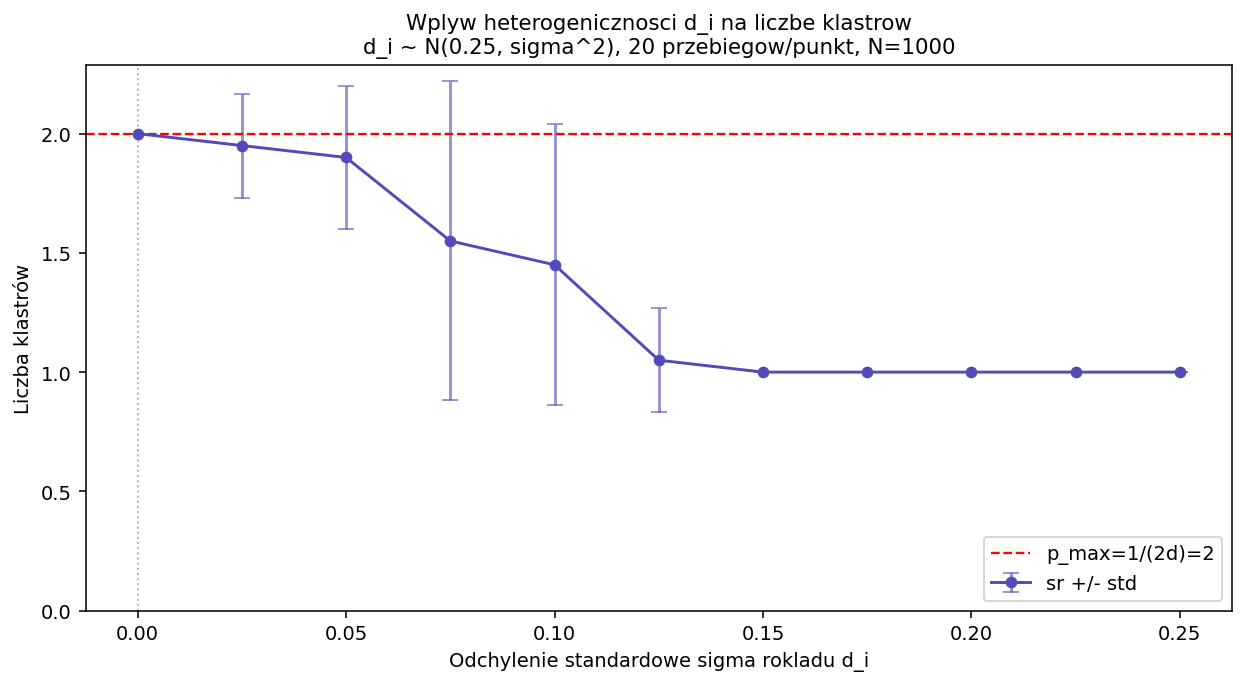


--- Interpretacja wyników ---
  sigma=0.025: sr=1.95  ( brak zmiany  Delta=-0.05 vs sigma=0)
  sigma=0.050: sr=1.90  ( brak zmiany  Delta=-0.10 vs sigma=0)
  sigma=0.075: sr=1.55  (      spadek  Delta=-0.45 vs sigma=0)
  sigma=0.100: sr=1.45  (      spadek  Delta=-0.55 vs sigma=0)
  sigma=0.125: sr=1.05  (      spadek  Delta=-0.95 vs sigma=0)
  sigma=0.150: sr=1.00  (      spadek  Delta=-1.00 vs sigma=0)
  sigma=0.175: sr=1.00  (      spadek  Delta=-1.00 vs sigma=0)
  sigma=0.200: sr=1.00  (      spadek  Delta=-1.00 vs sigma=0)
  sigma=0.225: sr=1.00  (      spadek  Delta=-1.00 vs sigma=0)
  sigma=0.250: sr=1.00  (      spadek  Delta=-1.00 vs sigma=0)


In [14]:
# --- Eksperyment 2: statystyka liczby klastrów vs sigma (wiele przebiegów) ---
d_mean    = 0.25
sigma_arr = np.arange(0.0, 0.26, 0.025)
n_rep     = 20

wyniki_h = {}
print(f'Statystyka klastrów vs sigma  (d_mean={d_mean}, {n_rep} powtórzen/punkt)')
print(f'{"sigma":>8}  {"sr. klastrów":>14}  {"min":>6}  {"max":>6}')
print('-' * 40)

for sig in sigma_arr:
    wyniki_h[sig] = []
    for rep in range(n_rep):
        if sig == 0.0:
            _, _, xf_s = deffuant(N=1000, d=d_mean, mu=0.5,
                                   n_steps=500_000)
        else:
            _, _, xf_s = deffuant_hetero(
                N=1000, d_mean=d_mean, d_sigma=float(sig),
                mu=0.5, n_steps=500_000)
        wyniki_h[sig].append(policz_klastry(xf_s, d=d_mean))
    m = np.mean(wyniki_h[sig])
    print(f'{sig:>8.3f}  {m:>14.2f}  '
          f'{min(wyniki_h[sig]):>6}  {max(wyniki_h[sig]):>6}')

fig, ax = plt.subplots(figsize=(9, 5))
means = [np.mean(wyniki_h[s]) for s in sigma_arr]
stds  = [np.std(wyniki_h[s])  for s in sigma_arr]
ax.errorbar(sigma_arr, means, yerr=stds,
            fmt='o-', color='#534AB7', ecolor='#534AB799',
            capsize=4, lw=1.5, ms=5, label='sr +/- std')
ax.axhline(int(1 / (2 * d_mean)), color='red', ls='--', lw=1.2,
           label=f'p_max=1/(2d)={int(1/(2*d_mean))}')
ax.axvline(0, color='gray', ls=':', lw=1.0, alpha=0.6)
ax.set_xlabel('Odchylenie standardowe sigma rokladu d_i')
ax.set_ylabel('Liczba klastrów')
ax.set_title(
    f'Wplyw heterogenicznosci d_i na liczbe klastrow\n'
    f'd_i ~ N({d_mean}, sigma^2), '
    f'{n_rep} przebiegow/punkt, N=1000'
)
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

print('\n--- Interpretacja wyników ---')
sigma0_mean = np.mean(wyniki_h[sigma_arr[0]])
for sig in sigma_arr[1:]:
    m = np.mean(wyniki_h[sig])
    delta = m - sigma0_mean
    trend = 'wzrost' if delta > 0.3 else ('spadek' if delta < -0.3 else 'brak zmiany')
    print(f'  sigma={sig:.3f}: sr={m:.2f}  ({trend:>12}  Delta={delta:+.2f} vs sigma=0)')


### Interpretacja §9

**Co obserwujemy:**

- **σ = 0 (klasyczny):** wszyscy agenci mają $d_i = \bar{d} = 0.25$, oczekiwane $p_{\max} = 2$ klastry.

- **Małe σ (0.05–0.10):** niewielka heterogeniczność nie zmienia istotnie liczby klastrów. 
Agenci z $d_i > \bar{d}$ mogą działać jako mosty, łącząc grupy które by się nie spotkały, 
ale efekt jest słaby gdy odchylenia są małe.

- **Duże σ (0.15–0.20):** znacząca heterogeniczność **zmniejsza** liczbę klastrów 
(tendencja do konsensusu). Agenci z bardzo dużym $d_i$ to lokalne centra grawitacji — 
przyciągają nawet dalekie opinie i sklejają klastry, które w modelu jednorodnym by się 
nie spotkały. Efekt analogiczny do **liderów opinii** w populacji.

- **Scatter $d_i$ vs opinia końcowa:** brak silnej zależności między progiem $d_i$ 
a ostateczną pozycją agenta. Wpływ otwartości jest pośredni (katalityczny), nie bezpośredni.

**Efektywny próg:** heterogeniczne $d_i$ daje $d_{\text{eff}} = \mathbb{E}[\min(d_i, d_j)] < \bar{d}$ 
(bo $\min$ jest wklęsłe). Przy małych σ dominuje ten efekt → więcej klastrów; 
przy dużych σ dominuje efekt mostów → mniej klastrów.


---
## Podsumowanie

| Sekcja | Co odtworzono | Odpowiednik |
|--------|--------------|-------------|
| §2 | Ewolucja, histogram, końcowe vs początkowe | Rys. 1–3 |
| §3 | Porównanie progów $d$ | Rys. 4 |
| §4 | Statystyka klastrów vs $d$ | Rys. 4 |
| §5 | Wpływ $\mu$ | Sekcja 2.2 |
| §6 | Siatka — trzy reżimy | Rys. 5–7 |
| §7 | Opinie wektorowe — ortogonalizacja | Rys. 8–9 |
